# ALS Implicit

## Роль notebook

Первый практический шаг в `advanced`.

Здесь мы не меняем сразу и датасет, и постановку, и архитектуру.
Цель notebook: показать переход от `item-item CF` к latent factors на знакомом `MovieLens`-сценарии.

## План

- собрать упрощённый `implicit` сигнал из положительных рейтингов;
- сохранить честный split и baseline comparison;
- обучить модель `ALS` из библиотеки `implicit`;
- получить top-K рекомендации;
- сравнить результат с `popularity baseline` и коллаборативной моделью.

## Validation checklist

- notebook запускается сверху вниз;
- ID mapping воспроизводим;
- already seen items отфильтрованы там, где это требуется;
- в выдаче нет дублей;
- различие между `explicit` и `implicit` постановкой объяснено явно;
- notebook использует реальную библиотеку `implicit`, а не самодельную замену.


## Требование к окружению

Этот notebook должен использовать реальную библиотеку `implicit`.
Если она не установлена, выполнение нужно остановить и сначала установить зависимость.


## Интуиция

После `item-item CF` у нас уже есть сильный collaborative baseline.
Но эта модель всё ещё опирается на похожесть объектов по соседям.

`ALS` предлагает другой взгляд:

- у каждого пользователя есть скрытый вектор предпочтений;
- у каждого объекта есть скрытый вектор свойств;
- score получается через совместимость этих двух векторов.

В этом notebook мы не пытаемся построить production-scale факторизацию.
Наша задача скромнее: честно показать, как latent factor модель ведёт себя на той же базовой top-K задаче, что и уже знакомые baseline'ы.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display


def find_project_root(start_path: Path) -> Path:
    for candidate in [start_path, *start_path.parents]:
        if (candidate / "src" / "recsys_basics").exists():
            return candidate
    raise FileNotFoundError("Не удалось найти корень проекта с папкой src/recsys_basics")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
plt.style.use("ggplot")

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"SRC_DIR: {SRC_DIR}")


PROJECT_ROOT: /Users/bobrsubr/PycharmProjects/_researches/recommender-systems-from-zero
SRC_DIR: /Users/bobrsubr/PycharmProjects/_researches/recommender-systems-from-zero/src


In [2]:
try:
    from implicit.als import AlternatingLeastSquares
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "Библиотека `implicit` не установлена. Установите её в окружение проекта (`pip install implicit` или `pip install -r requirements.txt`) и перезапустите notebook."
    ) from exc

from recsys_basics.advanced.als import ImplicitALSRecommender
from recsys_basics.basic.item_item import ItemItemRecommender
from recsys_basics.basic.popularity import (
    PopularityRecommender,
    build_seen_items_map,
    filter_positive_explicit_feedback,
)
from recsys_basics.data import build_explicit_interactions, get_movielens_data_dir, load_movielens_frames
from recsys_basics.metrics import evaluate_ranking_metrics
from recsys_basics.split import assert_no_user_time_leakage, leave_last_two_out_split

DATA_DIR = get_movielens_data_dir()
MIN_RATING = 4.0
TOP_K = 10

frames = load_movielens_frames(DATA_DIR)
interactions_df = build_explicit_interactions(frames.ratings)
movies_df = frames.movies.rename(columns={"movieId": "item_id"}).copy()

print(f"Interactions loaded: {len(interactions_df):,}")
print(f"Movies loaded: {len(movies_df):,}")
display(interactions_df.head())


Interactions loaded: 100,836
Movies loaded: 9,742


,user_id,item_id,rating,timestamp
0,429,22,4.0000,1996-03-29 18:36:55+00:00
1,429,150,5.0000,1996-03-29 18:36:55+00:00
2,429,161,5.0000,1996-03-29 18:36:55+00:00
3,429,165,4.0000,1996-03-29 18:36:55+00:00
4,429,218,4.0000,1996-03-29 18:36:55+00:00


## Превращаем explicit ratings в учебный implicit сигнал

`MovieLens` содержит `explicit ratings`, но для первого шага в `ALS` нам нужен упрощённый implicit-сценарий.

Сделаем это максимально честно и просто:

- рейтинг `>= 4.0` считаем положительным взаимодействием;
- более низкие рейтинги **не** считаем явными негативами;
- мы просто строим бинарную top-K задачу: какие объекты пользователь явно оценил достаточно высоко.


In [3]:
positive_df = filter_positive_explicit_feedback(interactions_df, min_rating=MIN_RATING)

conversion_summary = pd.DataFrame(
    {
        "metric": [
            "all_explicit_interactions",
            "positive_interactions",
            "positive_share",
            "users_with_positive_feedback",
            "items_with_positive_feedback",
        ],
        "value": [
            len(interactions_df),
            len(positive_df),
            len(positive_df) / len(interactions_df),
            positive_df["user_id"].nunique(),
            positive_df["item_id"].nunique(),
        ],
    }
)

display(conversion_summary)
display(positive_df.head())


,metric,value
0,all_explicit_interactions,"100,836.0000"
1,positive_interactions,"48,580.0000"
2,positive_share,0.4818
3,users_with_positive_feedback,609.0000
4,items_with_positive_feedback,"6,298.0000"


,user_id,item_id,rating,timestamp,event
0,429,22,4.0000,1996-03-29 18:36:55+00:00,positive_rating
1,429,150,5.0000,1996-03-29 18:36:55+00:00,positive_rating
2,429,161,5.0000,1996-03-29 18:36:55+00:00,positive_rating
3,429,165,4.0000,1996-03-29 18:36:55+00:00,positive_rating
4,429,218,4.0000,1996-03-29 18:36:55+00:00,positive_rating


## Split без leakage

Начиная с `advanced`, делаем split строже, чем в `basic`:

- для каждого пользователя последнее по времени положительное взаимодействие уходит в `test`;
- предпоследнее положительное взаимодействие уходит в `validation`;
- все более ранние положительные взаимодействия остаются в `train`.

Это важно:

- модели и feature-решения теперь сравниваются по `validation`;
- `test` остаётся отложенным набором и не участвует в выборе модели.

Здесь `train / validation / test` делятся не по фиксированным процентам, а по временной логике на пользователя.
Поэтому `validation` и `test` получаются маленькими по числу строк, но это нормально: их задача не занять условные `10%` датасета, а дать по одному честному отложенному примеру на каждого пользователя.


In [4]:
split_result = leave_last_two_out_split(positive_df, min_user_interactions=3)
train_df = split_result.train
val_df = split_result.validation
test_df = split_result.test

assert_no_user_time_leakage(train_df, val_df)
assert_no_user_time_leakage(pd.concat([train_df, val_df], ignore_index=True), test_df)

split_summary = pd.DataFrame(
    {
        "metric": [
            "train_rows",
            "validation_rows",
            "test_rows",
            "train_users",
            "validation_users",
            "test_users",
            "train_items",
            "validation_items",
            "test_items",
        ],
        "value": [
            len(train_df),
            len(val_df),
            len(test_df),
            train_df["user_id"].nunique(),
            val_df["user_id"].nunique(),
            test_df["user_id"].nunique(),
            train_df["item_id"].nunique(),
            val_df["item_id"].nunique(),
            test_df["item_id"].nunique(),
        ],
    }
)

display(split_summary)
display(val_df.head())


,metric,value
0,train_rows,47363
1,validation_rows,608
2,test_rows,608
3,train_users,608
4,validation_users,608
5,test_users,608
6,train_items,6227
7,validation_items,488
8,test_items,503


,user_id,item_id,rating,timestamp,event
0,1,2012,4.0000,2000-07-30 19:09:36+00:00,positive_rating
1,2,122882,5.0000,2015-10-24 19:34:32+00:00,positive_rating
2,3,7899,4.5000,2011-05-27 02:40:36+00:00,positive_rating
3,4,4896,4.0000,2001-12-05 17:48:52+00:00,positive_rating
4,5,247,5.0000,1996-11-08 06:42:17+00:00,positive_rating


## Обучаем baseline, коллаборативную модель и ALS

Чтобы сравнение было честным, обучим на одном и том же `train` три модели:

- `popularity baseline`;
- коллаборативную модель;
- `implicit ALS`.

Дальше будем сравнивать их на `validation`, а `test` пока оставим нетронутым.


In [5]:
seen_items_map = build_seen_items_map(train_df)
all_user_ids = sorted(val_df["user_id"].unique().tolist())
user_histories = train_df.groupby("user_id")["item_id"].agg(list).to_dict()

popularity_model = PopularityRecommender().fit(train_df)
collaborative_model = ItemItemRecommender().fit(train_df)
als_model = ImplicitALSRecommender(
    n_factors=16,
    n_iterations=8,
    regularization=0.1,
    alpha=20.0,
    random_state=42,
).fit(train_df)

print(f"Users in ALS model: {len(als_model.user_to_index_):,}")
print(f"Items in ALS model: {len(als_model.item_to_index_):,}")
print(f"Interaction matrix shape: {als_model.interaction_matrix_.shape}")
print(f"User factors shape: {als_model.user_factors_.shape}")
print(f"Item factors shape: {als_model.item_factors_.shape}")


  0%|          | 0/8 [00:00<?, ?it/s]

Users in ALS model: 608
Items in ALS model: 6,227
Interaction matrix shape: (608, 6227)
User factors shape: (608, 16)
Item factors shape: (6227, 16)


## Пример рекомендаций для нескольких пользователей

Сначала сделаем qualitative sanity-check на `validation`.
Нас интересует не только метрика, но и то, как выглядят рекомендации глазами человека.


In [6]:
popularity_recs = popularity_model.recommend_many(all_user_ids, seen_items_map=seen_items_map, k=TOP_K)
collaborative_recs = collaborative_model.recommend_many(user_histories, seen_items_map=seen_items_map, k=TOP_K)
als_recs = als_model.recommend_many(all_user_ids, seen_items_map=seen_items_map, k=TOP_K)

val_items_map = val_df.set_index("user_id")["item_id"].to_dict()

def hit_user_ids(recommendations: pd.DataFrame) -> list[int]:
    rec_map = recommendations.groupby("user_id")["item_id"].agg(list).to_dict()
    return [user_id for user_id, item_id in val_items_map.items() if item_id in rec_map.get(user_id, [])]


als_hit_users = hit_user_ids(als_recs)
sample_user_ids = als_hit_users[:3] if als_hit_users else all_user_ids[:3]
sample_rows = []

for user_id in sample_user_ids:
    val_item_id = int(val_items_map[user_id])
    val_title = movies_df.loc[movies_df["item_id"] == val_item_id, "title"].iloc[0]
    for model_name, recommendations_df in [
        ("popularity", popularity_recs),
        ("коллаборативная модель", collaborative_recs),
        ("als", als_recs),
    ]:
        recommended_ids = recommendations_df.loc[
            recommendations_df["user_id"] == user_id, "item_id"
        ].tolist()
        recommended_titles = movies_df[movies_df["item_id"].isin(recommended_ids)][["item_id", "title"]]
        sample_rows.append(
            {
                "user_id": user_id,
                "model": model_name,
                "validation_item_id": val_item_id,
                "validation_title": val_title,
                "hit_at_10": val_item_id in recommended_ids,
                "recommended_titles": recommended_titles["title"].tolist()[:5],
            }
        )

display(pd.DataFrame(sample_rows))


,user_id,model,validation_item_id,validation_title,hit_at_10,recommended_titles
0,26,popularity,47,Seven (a.k.a. Se7en) (1995),False,"[Usual Suspects, The (1995), Braveheart (1995)..."
1,26,коллаборативная модель,47,Seven (a.k.a. Se7en) (1995),True,"[Seven (a.k.a. Se7en) (1995), Usual Suspects, ..."
2,26,als,47,Seven (a.k.a. Se7en) (1995),True,"[Seven (a.k.a. Se7en) (1995), Braveheart (1995..."
3,35,popularity,590,Dances with Wolves (1990),False,"[Braveheart (1995), Star Wars: Episode IV - A ..."
4,35,коллаборативная модель,590,Dances with Wolves (1990),True,"[Babe (1995), Pulp Fiction (1994), Forrest Gum..."
5,35,als,590,Dances with Wolves (1990),True,"[Babe (1995), Braveheart (1995), Crimson Tide ..."
6,54,popularity,593,"Silence of the Lambs, The (1991)",True,"[Usual Suspects, The (1995), Braveheart (1995)..."
7,54,коллаборативная модель,593,"Silence of the Lambs, The (1991)",True,"[Usual Suspects, The (1995), Braveheart (1995)..."
8,54,als,593,"Silence of the Lambs, The (1991)",True,"[Toy Story (1995), Usual Suspects, The (1995),..."


## Количественное сравнение

Теперь посмотрим на те же top-K метрики, что использовались раньше, но уже на `validation`.
В этой постановке у каждого пользователя в `validation` ровно один релевантный объект, поэтому `Recall@10` и `HitRate@10` совпадут.


In [9]:
def summarize_metrics(name: str, recommendations: pd.DataFrame, k: int = TOP_K) -> dict[str, float | str]:
    metrics_df = evaluate_ranking_metrics(val_df, recommendations, k=k)
    unique_items = recommendations["item_id"].nunique() if not recommendations.empty else 0
    catalog_items = train_df["item_id"].nunique()
    summary = {"model": name}
    for column in metrics_df.columns:
        if column == "user_id":
            continue
        summary[column] = float(metrics_df[column].mean())
    summary["catalog_coverage"] = unique_items / catalog_items if catalog_items else 0.0
    summary["unique_recommended_items"] = int(unique_items)
    return summary


metrics_summary = pd.DataFrame(
    [
        summarize_metrics("popularity", popularity_recs),
        summarize_metrics("item-item collaborative filtering", collaborative_recs),
        summarize_metrics("als", als_recs),
    ]
)

display(metrics_summary)


,model,precision@10,recall@10,hit_rate@10,map@10,ndcg@10,catalog_coverage,unique_recommended_items
0,popularity,0.0044,0.0444,0.0444,0.0120,0.0194,0.0098,61
1,item-item collaborative filtering,0.0071,0.0707,0.0707,0.0225,0.0336,0.0732,456
2,als,0.0064,0.0641,0.0641,0.0208,0.0309,0.1200,747


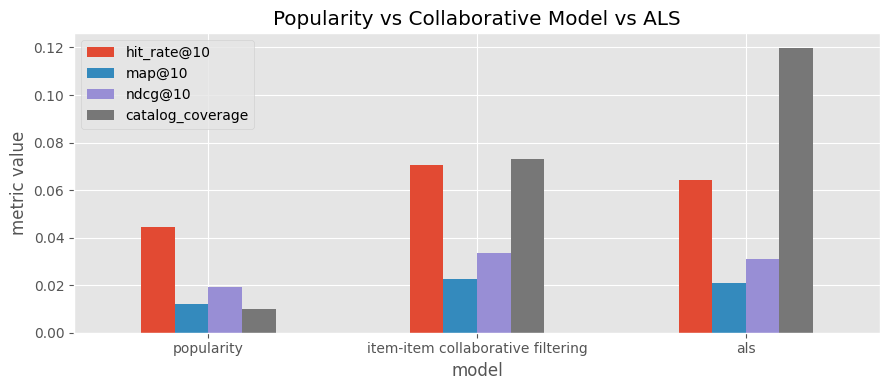

In [10]:
plot_df = metrics_summary.set_index("model")[["hit_rate@10", "map@10", "ndcg@10", "catalog_coverage"]]
plot_df.plot(kind="bar", figsize=(9, 4), rot=0, title="Popularity vs Collaborative Model vs ALS")
plt.ylabel("metric value")
plt.tight_layout()
plt.show()


## Как интерпретировать результат

В этом validation-прогоне `ALS` обыгрывает `popularity baseline`, но пока не обгоняет `item-item` коллаборативную модель.

Здесь важнее другой учебный вывод:

- мы сравниваем два разных класса коллаборативных моделей в одной и той же постановке;
- `item-item` опирается на neighbourhood-логику, а `ALS` учит latent factors пользователей и объектов;
- более advanced-модель не обязана автоматически выигрывать на маленьком учебном `MovieLens`;
- у `ALS` здесь шире `catalog coverage`, то есть модель охватывает более широкий набор объектов;
- `test` мы пока не трогаем, чтобы дальше в `advanced` честно использовать его как отложенную проверку.

Также нужно помнить ограничения:

- мы всё ещё работаем на учебном `MovieLens`;
- cold-start для новых объектов и новых пользователей никуда не исчез;
- item-features модель пока ещё не использует.


## Что дальше

Следующий шаг в маршруте: [02a_lightfm_hybrid_factorization.ipynb](../../notebooks/advanced/02a_lightfm_hybrid_factorization.ipynb).

Там мы сохраним factorization-логику, но добавим к ней признаки объектов и посмотрим, как hybrid-постановка меняет модель и её учебный смысл.
